<a href="https://colab.research.google.com/github/kidxcudi/ML_lab_model_2/blob/main/wine_quality_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import os
import json
from datetime import datetime
import shutil

In [ ]:
# Load data
df = pd.read_csv("/content/winequality-red.csv")
print(f"Initial dataset: {df.shape[0]:,} records")

Initial dataset: 1,599 records


In [ ]:
print(f"\nDataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print("\nFirst few rows:")
print(df.head())


Dataset loaded: 1599 samples, 12 features

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0   

In [ ]:
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Statistical Summary:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599

In [ ]:
# Check missing values
print("\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values!")
else:
    print(missing[missing > 0])


Missing values:
No missing values!


In [ ]:
# Original quality distribution
print("\n🍷 Original Quality Distribution (0-10 scale):")
print(df['quality'].value_counts().sort_index())


🍷 Original Quality Distribution (0-10 scale):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


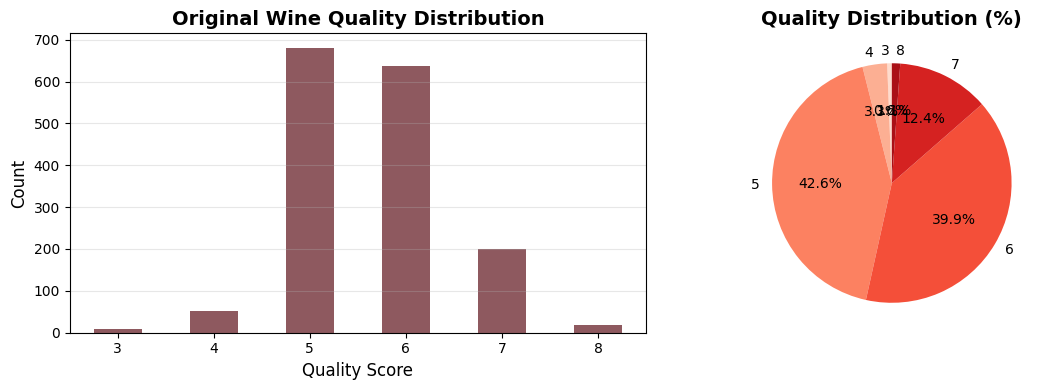

In [ ]:
# Visualize original distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['quality'].value_counts().sort_index().plot(kind='bar', color='#722f37', alpha=0.8)
plt.title('Original Wine Quality Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(df['quality'].value_counts().sort_index(),
        labels=df['quality'].value_counts().sort_index().index,
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Reds", 6))
plt.title('Quality Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

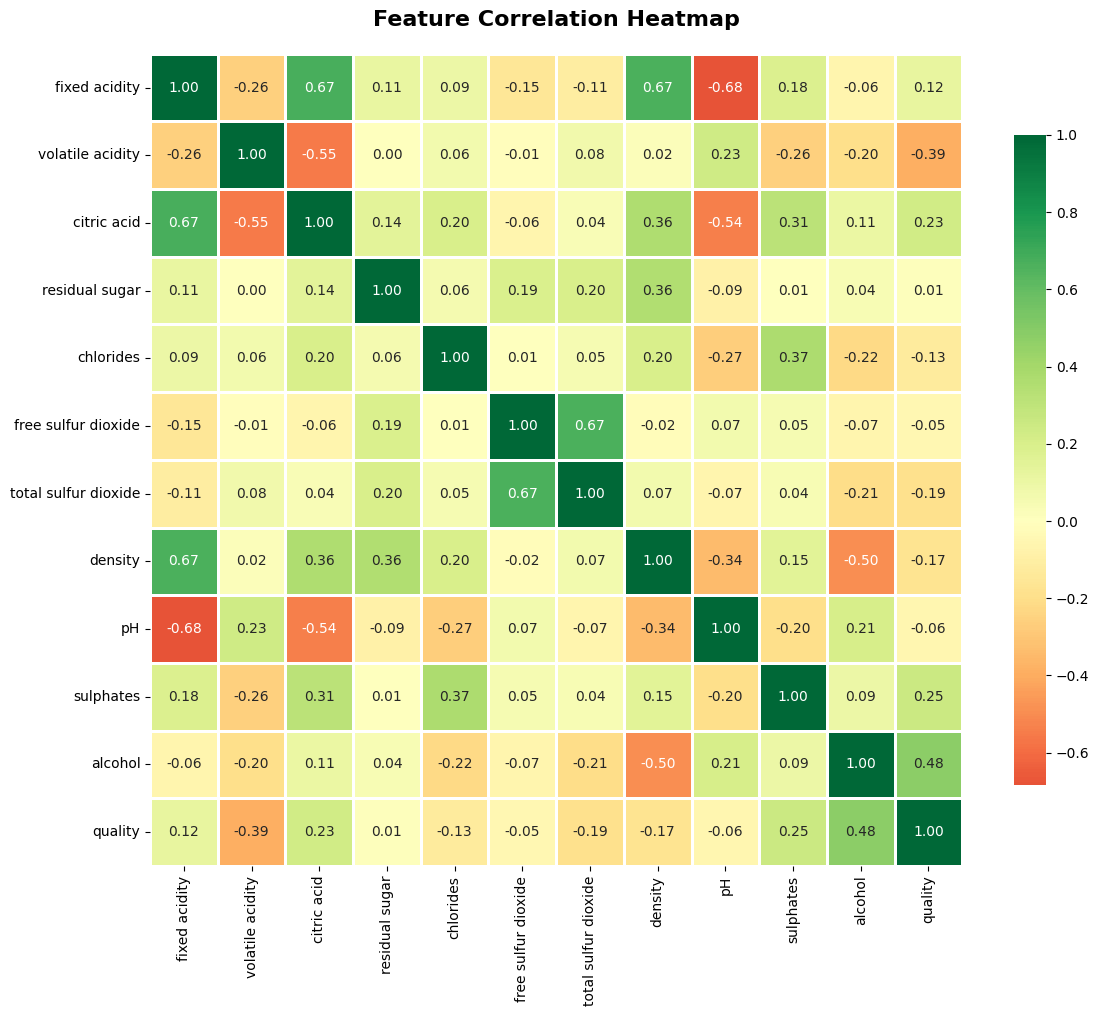

In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Feature correlation
correlation = df.corr()
print("\n🔬 Features correlated with quality:")
print(correlation['quality'].sort_values(ascending=False))


🔬 Features correlated with quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:
# Create 3-class target
def classify_quality(score):
    if score <= 4:
        return 'Substandard'
    elif score <= 6:
        return 'Satisfactory'
    else:
        return 'Premium'

df['quality_class'] = df['quality'].apply(classify_quality)

In [ ]:
print("\n3-Class Distribution:")
class_counts = df['quality_class'].value_counts()
print(class_counts)


3-Class Distribution:
quality_class
Satisfactory    1319
Premium          217
Substandard       63
Name: count, dtype: int64


In [ ]:
print("\nPercentages:")
class_pcts = (class_counts / len(df) * 100).round(2)
for quality_class, pct in class_pcts.items():
    print(f"   {quality_class:8s}: {pct:5.2f}%")


Percentages:
   Satisfactory: 82.49%
   Premium : 13.57%
   Substandard:  3.94%


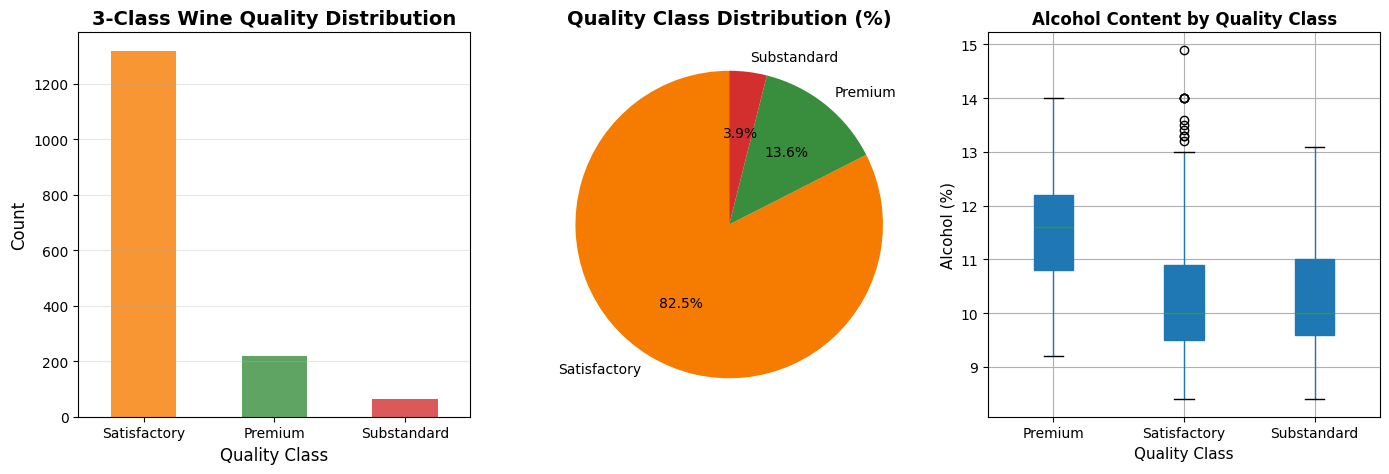

In [ ]:
# Visualize 3-class distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
colors_dict = {'Substandard': '#d32f2f', 'Satisfactory': '#f57c00', 'Premium': '#388e3c'}
class_counts.plot(kind='bar', color=[colors_dict[x] for x in class_counts.index], alpha=0.8)
plt.title('3-Class Wine Quality Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
        colors=[colors_dict[x] for x in class_counts.index], startangle=90)
plt.title('Quality Class Distribution (%)', fontsize=14, fontweight='bold')

plt.subplot(1, 3, 3)
# Box plot: Alcohol content by quality class
df.boxplot(column='alcohol', by='quality_class', figsize=(8, 5),
           patch_artist=True, ax=plt.gca())
plt.title('Alcohol Content by Quality Class', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Quality Class', fontsize=11)
plt.ylabel('Alcohol (%)', fontsize=11)

plt.tight_layout()
plt.show()

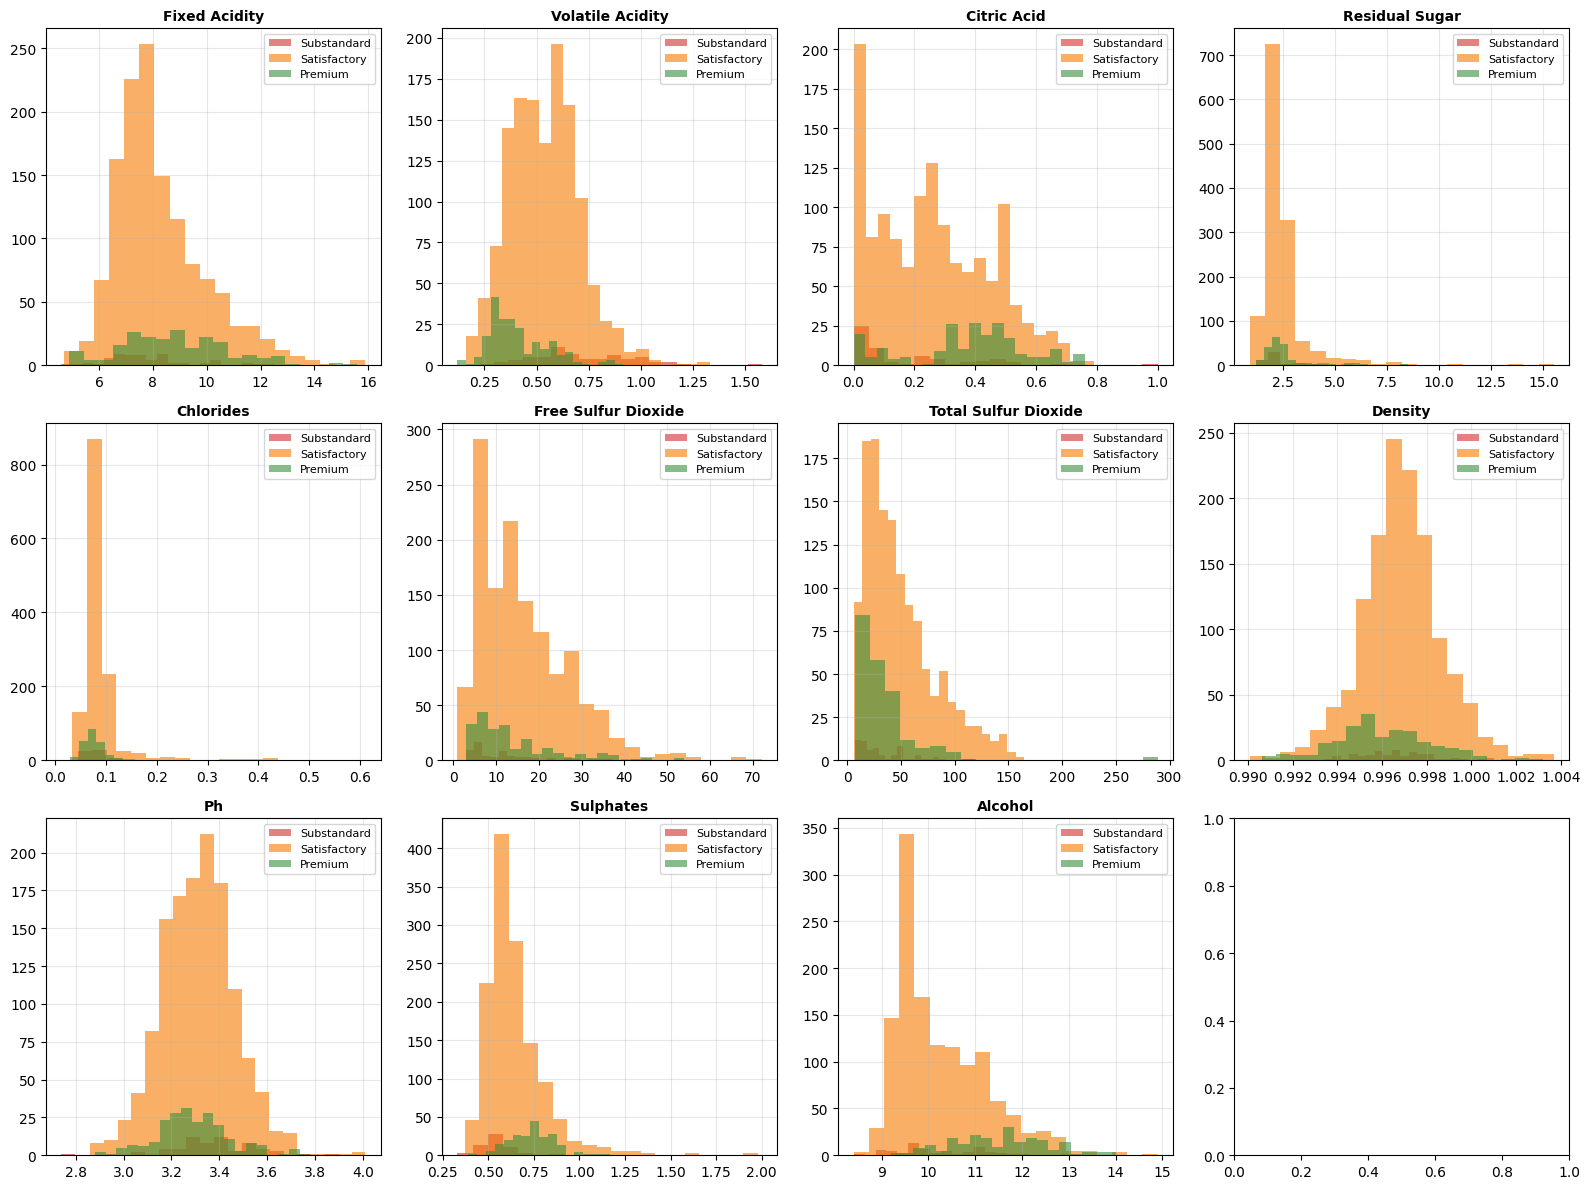

In [ ]:
# Feature distributions by class
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
features = df.columns[:-2]  # Exclude 'quality' and 'quality_class'

for idx, feature in enumerate(features):
    ax = axes[idx // 4, idx % 4]
    for quality_class in ['Substandard', 'Satisfactory', 'Premium']:
        df[df['quality_class'] == quality_class][feature].hist(
            ax=ax, alpha=0.6, bins=20, label=quality_class,
            color=colors_dict[quality_class]
        )
    ax.set_title(feature.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Features and target
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

In [ ]:
print(f"\nFeatures: {list(X.columns)}")
print(f"Target: quality_class")
print(f"Shape: X={X.shape}, y={y.shape}")


Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target: quality_class
Shape: X=(1599, 11), y=(1599,)


In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(f"\nData Split:")
print(f"   Training:   {len(X_train):>5} samples (80%)")
print(f"   Testing:    {len(X_test):>5} samples (20%)")


Data Split:
   Training:    1279 samples (80%)
   Testing:      320 samples (20%)


In [ ]:
print("\nTraining set class distribution:")
train_dist = y_train.value_counts()
for quality_class, count in train_dist.items():
    pct = (count / len(y_train)) * 100
    print(f"   {quality_class:8s}: {count:>4} ({pct:5.2f}%)")


Training set class distribution:
   Satisfactory: 1055 (82.49%)
   Premium :  174 (13.60%)
   Substandard:   50 ( 3.91%)


In [ ]:
print("\nBefore SMOTE:")
print(y_train.value_counts())


Before SMOTE:
quality_class
Satisfactory    1055
Premium          174
Substandard       50
Name: count, dtype: int64


In [ ]:
print("\nCreating Pipeline...")

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        random_state=42
    )),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

print("Pipeline created:")
print("   1. StandardScaler")
print("   2. SMOTE")
print("   3. DecisionTreeClassifier")


Creating Pipeline...
Pipeline created:
   1. StandardScaler
   2. SMOTE
   3. DecisionTreeClassifier


In [ ]:
# Define grid - prefix with 'classifier__' for pipeline
param_grid = {
    'classifier__max_depth': [10, 15, 20, 25, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': ['balanced', None]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)
print("\nTraining complete!")

Fitting 5 folds for each of 320 candidates, totalling 1600 fits

Training complete!


In [ ]:
# Best parameters
print("\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    clean_param = param.replace('classifier__', '')
    print(f"   {clean_param}: {value}")

print(f"\nBest CV Score: {grid_search.best_score_:.4f}")


Best Hyperparameters:
   class_weight: balanced
   criterion: entropy
   max_depth: 15
   min_samples_leaf: 1
   min_samples_split: 5

Best CV Score: 0.5880


In [ ]:
best_pipeline = grid_search.best_estimator_

In [ ]:
print("\nCalibrating Decision Tree probabilities (isotonic)...")

# 1. Extract the trained classifier
base_classifier = best_pipeline.named_steps['classifier']

# 2. Create calibrated classifier
calibrated_classifier = CalibratedClassifierCV(
    estimator=clone(base_classifier),
    method="isotonic",
    cv=5
)

# 3. Fit calibration on ORIGINAL training data (NO SMOTE)
#    IMPORTANT: use scaled features only
scaler = best_pipeline.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

calibrated_classifier.fit(X_train_scaled, y_train)

print("Calibration complete")

# 4. Replace classifier in pipeline with calibrated version
best_pipeline.named_steps['classifier'] = calibrated_classifier



Calibrating Decision Tree probabilities (isotonic)...
Calibration complete


In [ ]:
print(best_pipeline.predict_proba(X_test[:5]))

[[0.   1.   0.  ]
 [0.   0.75 0.25]
 [0.   1.   0.  ]
 [0.   1.   0.  ]
 [0.   1.   0.  ]]


In [ ]:
# Predictions on test set
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)

In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

     Premium     0.4783    0.7674    0.5893        43
Satisfactory     0.9224    0.8106    0.8629       264
 Substandard     0.2105    0.3077    0.2500        13

    accuracy                         0.7844       320
   macro avg     0.5371    0.6286    0.5674       320
weighted avg     0.8338    0.7844    0.8012       320



In [ ]:
# Metrics
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

In [ ]:
print("\nOverall Metrics:")
print(f"   Accuracy:           {acc:.4f} ({acc*100:.2f}%)")
print(f"   Balanced Accuracy:  {bal_acc:.4f} ({bal_acc*100:.2f}%)")
print(f"   F1-Score (Macro):   {f1_macro:.4f}")
print(f"   F1-Score (Weighted): {f1_weighted:.4f}")


Overall Metrics:
   Accuracy:           0.7844 (78.44%)
   Balanced Accuracy:  0.6286 (62.86%)
   F1-Score (Macro):   0.5674
   F1-Score (Weighted): 0.8012


In [ ]:
# Per-class metrics
f1_per_class = f1_score(y_test, y_pred, average=None, labels=['Substandard', 'Satisfactory', 'Premium'])
print("\nPer-Class F1-Scores:")
for i, class_name in enumerate(['Substandard', 'Satisfactory', 'Premium']):
    print(f"   {class_name:8s}: {f1_per_class[i]:.4f}")


Per-Class F1-Scores:
   Substandard: 0.2500
   Satisfactory: 0.8629
   Premium : 0.5893


In [ ]:
# Performance assessment
if acc >= 0.80 and bal_acc >= 0.70:
    print("\nGOOD - Ready for deployment")
elif acc >= 0.75 and bal_acc >= 0.60:
    print("\nACCEPTABLE - Usable")
else:
    print("\n FAIR - Limited but functional")


ACCEPTABLE - Usable


<Axes: >

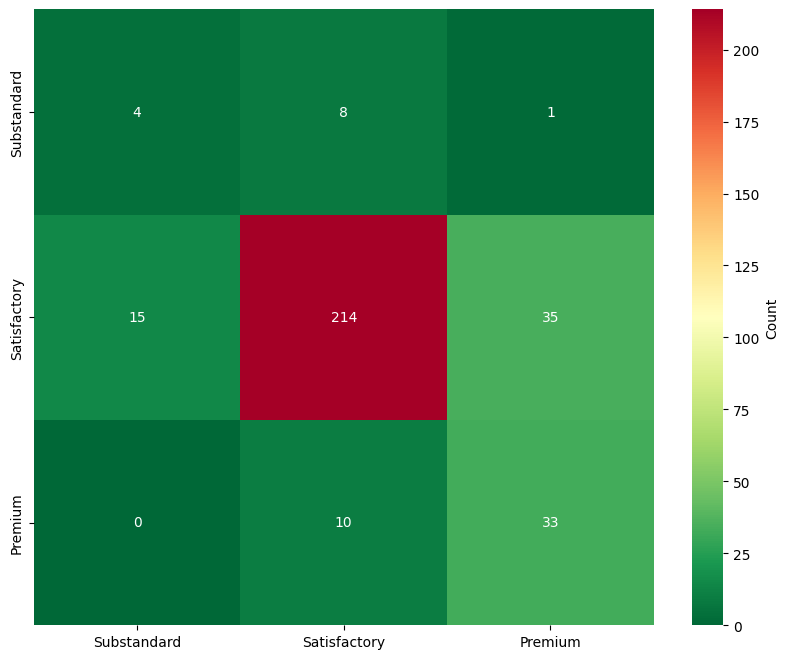

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Substandard', 'Satisfactory', 'Premium'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
            xticklabels=['Substandard', 'Satisfactory', 'Premium'],
            yticklabels=['Substandard', 'Satisfactory', 'Premium'],
            cbar_kws={'label': 'Count'})

In [ ]:
# Feature Importance
best_dt = best_pipeline.named_steps['classifier']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Features:")
print(feature_importance.head().to_string(index=False))


Top 5 Features:
         feature  importance
       sulphates    0.245897
         alcohol    0.172343
volatile acidity    0.157649
              pH    0.101822
  residual sugar    0.065710


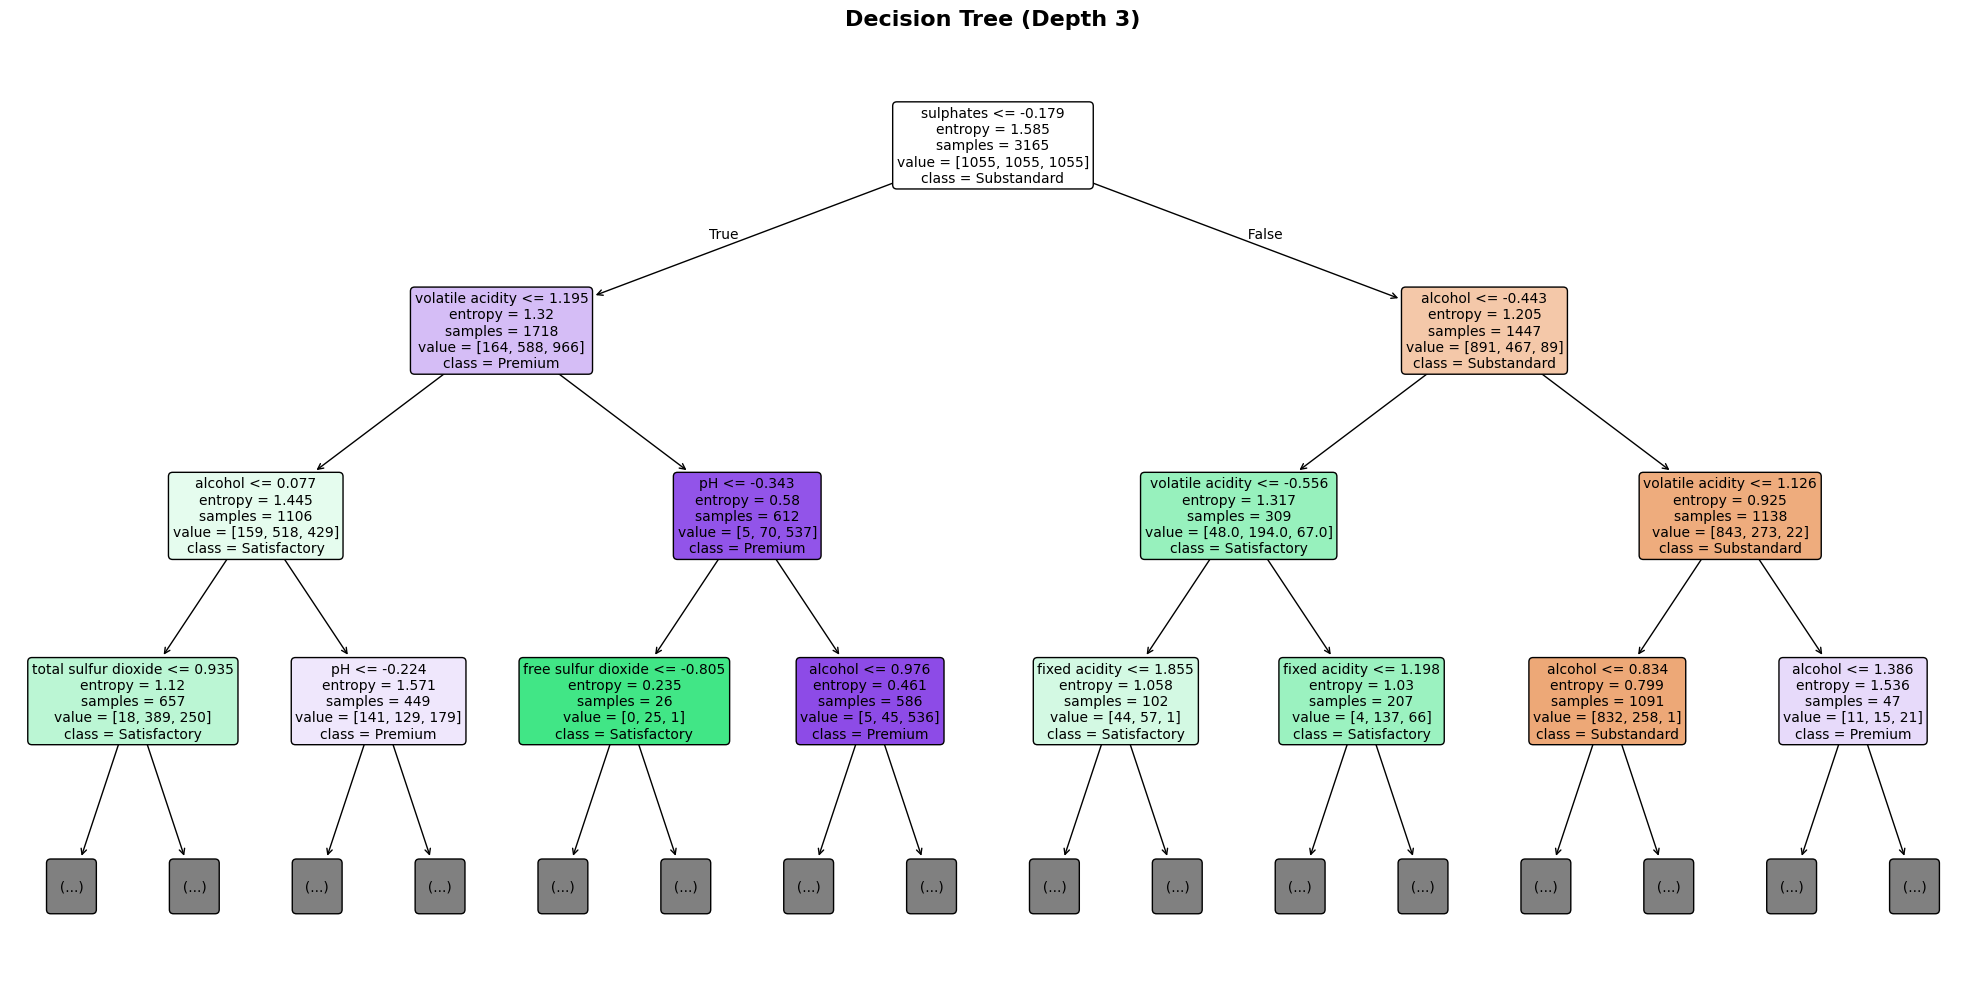


Tree: 15 depth, 226 leaves


In [ ]:
# Tree visualization
plt.figure(figsize=(20, 10))
plot_tree(best_dt,
          max_depth=3,
          feature_names=X.columns,
          class_names=['Substandard', 'Satisfactory', 'Premium'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (Depth 3)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nTree: {best_dt.get_depth()} depth, {best_dt.get_n_leaves()} leaves")

In [ ]:
print("Tree visualization saved (limited to depth 3 for readability)")
print(f"Actual tree depth: {best_dt.get_depth()}")
print(f"Actual tree leaves: {best_dt.get_n_leaves()}")

Tree visualization saved (limited to depth 3 for readability)
Actual tree depth: 15
Actual tree leaves: 226


In [ ]:
BUNDLE_DIR = "wine_quality_decision_tree"
os.makedirs(BUNDLE_DIR, exist_ok=True)

In [ ]:
#Save ENTIRE pipeline (contains scaler + SMOTE + model)
MODEL_PATH = os.path.join(BUNDLE_DIR, "model.joblib")
joblib.dump(best_pipeline, MODEL_PATH)

['wine_quality_decision_tree/model.joblib']

In [ ]:
print(f"Pipeline saved: {MODEL_PATH}")
print("   (Contains: StandardScaler + SMOTE + DecisionTree)")

Pipeline saved: wine_quality_decision_tree/model.joblib
   (Contains: StandardScaler + SMOTE + DecisionTree)


In [ ]:
# Schema
schema = {
    "name": "Wine Quality Predictor",
    "version": "2.0.0",
    "model_type": "Pipeline (StandardScaler + SMOTE + DecisionTree)",
    "classes": ["Ordinary", "Satisfactory", "Premium"],
    "class_mapping": {
        "Ordinary": "Quality 3-4: Basic wine",
        "Satisfactory": "Quality 5-6: Good wine",
        "Premium": "Quality 7-9: Excellent wine"
    },
    "features": list(X.columns),
    "feature_descriptions": {
        "fixed_acidity": "Tartaric acid (g/dm³)",
        "volatile_acidity": "Acetic acid (g/dm³)",
        "citric_acid": "Freshness (g/dm³)",
        "residual_sugar": "Sugar (g/dm³)",
        "chlorides": "Salt (g/dm³)",
        "free_sulfur_dioxide": "Free SO2 (mg/dm³)",
        "total_sulfur_dioxide": "Total SO2 (mg/dm³)",
        "density": "Density (g/cm³)",
        "pH": "Acidity (0-14)",
        "sulphates": "Additive (g/dm³)",
        "alcohol": "Alcohol (% vol)"
    },
    "preprocessing": {
        "pipeline_steps": ["StandardScaler", "SMOTE", "DecisionTree"],
        "note": "Pipeline handles all preprocessing automatically"
    },
    "hyperparameters": {
        k.replace('classifier__', ''): v
        for k, v in grid_search.best_params_.items()
    }
}

with open(os.path.join(BUNDLE_DIR, "schema.json"), "w") as f:
    json.dump(schema, f, indent=2)

In [ ]:
# Save metadata
metadata = {
    "dataset": {
        "name": "UCI Wine Quality (Red Wine)",
        "samples_total": len(df),
        "samples_train": len(X_train),
        "samples_test": len(X_test),
        "features": len(X.columns)
    },
    "class_distribution": {
        "Substandard": int(train_dist.get('Substandard', 0)),
        "Satisfactory": int(train_dist.get('Satisfactory', 0)),
        "Premium": int(train_dist.get('Premium', 0))
    },
    "performance": {
        "test_accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "f1_Substandard": float(f1_per_class[0]),
        "f1_Satisfactory": float(f1_per_class[1]),
        "f1_Premium": float(f1_per_class[2])
    },
    "model_details": {
        "tree_depth": int(best_dt.get_depth()),
        "tree_leaves": int(best_dt.get_n_leaves()),
        "best_cv_score": float(grid_search.best_score_)
    },
    "calibration": {
    "method": "isotonic",
    "cv": 5
  },
}
with open(os.path.join(BUNDLE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved")

Metadata saved


In [ ]:
# Example predictions
examples = []
for i in range(min(10, len(X_test))):
    wine = X_test.iloc[i:i+1]
    pred = best_pipeline.predict(wine)[0]
    proba = best_pipeline.predict_proba(wine)[0]

    examples.append({
        "wine_id": i + 1,
        "features": wine.iloc[0].to_dict(),
        "prediction": pred,
        "probabilities": {
            "Substandard": float(proba[0]),
            "Satisfactory": float(proba[1]),
            "Premium": float(proba[2])
        },
        "confidence": float(max(proba))
    })

with open(os.path.join(BUNDLE_DIR, "example_predictions.json"), "w") as f:
    json.dump(examples, f, indent=2)

In [ ]:
# Zip the bundle
zip_path = shutil.make_archive(BUNDLE_DIR, "zip", BUNDLE_DIR)
print(f"Bundle zipped: {zip_path}")

Bundle zipped: /content/wine_quality_decision_tree.zip
